In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv("./data/IMDB Dataset.csv")

In [3]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
df.sample(5)

,review,sentiment
16178,What is wrong with American movies these days?...,negative
11503,"This is the most boring, pretentious, and stup...",negative
46105,There are really two sections of this film. Fi...,negative
3132,"Loaded with fine actors, I expected much more ...",negative
19132,This movie is a great movie ONLY if you need s...,negative


In [5]:
df_pos = df[df['sentiment']=='positive'][:5000]
df_neg = df[df['sentiment']=='negative'][:5000]

df_reviews = pd.concat([df_pos, df_neg ])

In [6]:
from sklearn.model_selection import train_test_split


In [7]:
train,test = train_test_split(df_reviews,test_size =0.33,random_state=42)

In [8]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [9]:
train_y.value_counts()

sentiment
negative    3378
positive    3322
Name: count, dtype: int64

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from bs4 import BeautifulSoup
import re

def limpiar_texto(texto):
    texto = BeautifulSoup(texto, 'html.parser').get_text(' ')
    texto = re.sub(r"[^a-zA-Z']", ' ', texto)
    return texto.lower()

In [11]:
tfidf = TfidfVectorizer(
    stop_words='english',
    preprocessor=limpiar_texto
)
train_x_vector = tfidf.fit_transform(train_x)
test_x_vector = tfidf.transform(test_x)

In [12]:
train_x.shape

(6700,)

In [13]:
train_x_vector.shape

(6700, 43417)

In [14]:
type(train_x_vector)

scipy.sparse._csr.csr_matrix

In [15]:
primera_resenia = pd.Series(
    train_x_vector.getrow(0).toarray().ravel(),
    index=tfidf.get_feature_names_out(),
    name=train_x.index[0]
)

In [16]:
primera_resenia

aa              0.0
aaaaahhhh       0.0
aaaarrgh        0.0
aaah            0.0
aaall           0.0
               ... 
zurich          0.0
zwart           0.0
zwick           0.0
zz              0.0
zzzzzzzzzzzz    0.0
Name: 6746, Length: 43417, dtype: float64

In [17]:
train_x.iloc[0]

"I happened to rent this movie with my sister in hopes of watching a great entertaining movie, that was humorous, however my expectations were let down. This movie was beyond disgusting and revolting for a PG-13 movie, this should have been rated R for the many mature references that went on in this movie. I wouldn't recommend allowing a 13 year old teen see this.<br /><br />Even if no one under the age of 17 is watching this movie, beware of a truly stupid movie, there's no humor in the movie, just a bunch of disgusting sexual references including a small touch of pedophilia, something that shouldn't even be joked about. <br /><br />I would like to know what happened to PG-13 movies, that were actually safe for actual a 13 year old? This is beyond a deplorable movie and should be re-rated."

In [18]:
primera_resenia[primera_resenia != 0]

actual          0.105276
actually        0.070637
age             0.102017
allowing        0.147385
beware          0.164401
bunch           0.107031
deplorable      0.193238
disgusting      0.273469
entertaining    0.093194
expectations    0.118548
great           0.056164
happened        0.203256
hopes           0.131052
humor           0.097075
humorous        0.133911
including       0.100681
joked           0.193238
just            0.043300
know            0.062044
let             0.082691
like            0.041896
mature          0.144835
movie           0.317560
movies          0.059994
old             0.141953
pedophilia      0.198496
pg              0.297543
rated           0.237493
recommend       0.087574
references      0.260775
rent            0.107153
revolting       0.174659
safe            0.137607
sexual          0.113409
shouldn         0.124357
sister          0.109192
small           0.090698
stupid          0.090820
teen            0.125393
touch           0.118947


In [19]:
train_x.iloc[0]

"I happened to rent this movie with my sister in hopes of watching a great entertaining movie, that was humorous, however my expectations were let down. This movie was beyond disgusting and revolting for a PG-13 movie, this should have been rated R for the many mature references that went on in this movie. I wouldn't recommend allowing a 13 year old teen see this.<br /><br />Even if no one under the age of 17 is watching this movie, beware of a truly stupid movie, there's no humor in the movie, just a bunch of disgusting sexual references including a small touch of pedophilia, something that shouldn't even be joked about. <br /><br />I would like to know what happened to PG-13 movies, that were actually safe for actual a 13 year old? This is beyond a deplorable movie and should be re-rated."

In [20]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(train_x_vector, train_y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
print(svc.predict(tfidf.transform(['A good movie'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie at all I gave this movie away'])))

['positive']
['positive']
['negative']


In [22]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

accuracy = svc.score(test_x_vector, test_y)
print(f'Precisión del modelo: {accuracy:.4%}')

Precisión del modelo: 87.1212%


In [23]:
f1_score(test_y,svc.predict(test_x_vector),
          labels = ['positive','negative'],average=None)

array([0.87444609, 0.86780715])

In [24]:
print(classification_report(test_y,
                            svc.predict(test_x_vector),
                            labels = ['positive','negative']))

              precision    recall  f1-score   support

    positive       0.87      0.88      0.87      1678
    negative       0.88      0.86      0.87      1622

    accuracy                           0.87      3300
   macro avg       0.87      0.87      0.87      3300
weighted avg       0.87      0.87      0.87      3300



In [25]:
conf_mat = confusion_matrix(test_y,
                           svc.predict(test_x_vector),
                           labels = ['positive', 'negative'])
conf_mat

array([[1480,  198],
       [ 227, 1395]])

## Comparación con otros modelos

Entrenamos Regresión Logística, Naive Bayes Gaussiano y Árbol de Decisión con la misma partición de datos. Para `GaussianNB` usamos `TruncatedSVD`: este modelo requiere una matriz densa y convertir directamente las 43 mil características consumiría demasiada memoria.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import TruncatedSVD

modelos = {
    'SVM lineal': svc,
    'Regresión logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de decisión': DecisionTreeClassifier(random_state=42),
}

predicciones = {'SVM lineal': svc.predict(test_x_vector)}
for nombre, modelo in modelos.items():
    if nombre != 'SVM lineal':
        modelo.fit(train_x_vector, train_y)
        predicciones[nombre] = modelo.predict(test_x_vector)

svd = TruncatedSVD(n_components=100, random_state=42)
train_x_reducido = svd.fit_transform(train_x_vector)
test_x_reducido = svd.transform(test_x_vector)
gaussian_nb = GaussianNB()
gaussian_nb.fit(train_x_reducido, train_y)
predicciones['GaussianNB + SVD'] = gaussian_nb.predict(test_x_reducido)

In [27]:
resultados = pd.DataFrame([
    {
        'Modelo': nombre,
        'Accuracy': (prediccion == test_y).mean(),
        'F1 macro': f1_score(test_y, prediccion, average='macro')
    }
    for nombre, prediccion in predicciones.items()
]).sort_values('F1 macro', ascending=False).reset_index(drop=True)
resultados

,Modelo,Accuracy,F1 macro
0,Regresión logística,0.876667,0.876585
1,SVM lineal,0.871212,0.871127
2,GaussianNB + SVD,0.740303,0.731698
3,Árbol de decisión,0.706970,0.706863


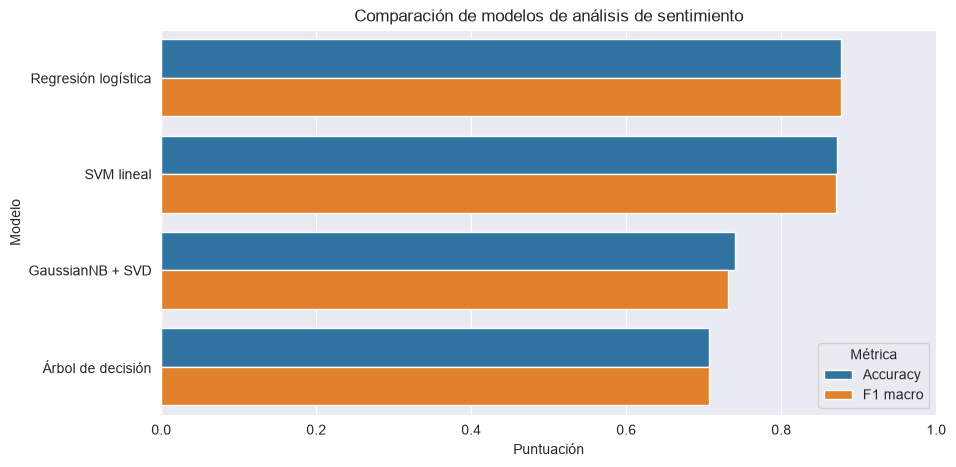

In [28]:
resultados_grafica = resultados.melt(
    id_vars='Modelo', var_name='Métrica', value_name='Puntuación'
)
plt.figure(figsize=(10, 5))
sns.barplot(data=resultados_grafica, x='Puntuación', y='Modelo', hue='Métrica')
plt.xlim(0, 1)
plt.title('Comparación de modelos de análisis de sentimiento')
plt.show()